Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and Global variables

In [2]:
# Constants
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Expression_TE_DESeq_Cingluate_cortex.csv"
DEA_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\DEA_TE_DESeq_Cingluate_cortex.csv"
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\SraRunTable_Aldinger20.csv"
INTERGENIC_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\TE_Intergenic_With_Distances_Cingluate_cortex.bed"

# Variables
expression_df = None
dea_df = None
genes_of_interest = None

Expression - Import

In [3]:
expression_df = pd.read_csv(EXPRESSION_FILE)
expression_df.rename(columns = {'Unnamed: 0' : 'TE'}, inplace = True)
expression_df.head()

,TE,GSM3673208,GSM3673209,GSM3673210,GSM3673211,GSM3673212,GSM3673213,GSM3673214,GSM3673215
0,TE_L1PA7_dup3,2,2,1,2,3,3,2,3
1,TE_Tigger5_dup3,6,31,52,4,42,8,29,6
2,TE_L1PA7_dup4,0,2,2,0,5,0,2,4
3,TE_L1PA7_dup5,6,0,0,3,1,0,0,1
4,TE_AluSq2_dup30,50,3,5,17,4,25,7,11


DEA - Import

In [4]:
dea_df = pd.read_csv(DEA_FILE)
dea_df.rename(columns = {'Unnamed: 0' : 'TE'}, inplace = True)
dea_df.dropna(subset =['padj'], inplace = True)
dea_df.head()

,TE,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,TE_L1M4_dup2331,10.858624,-4.180354,0.906788,-4.610067,0.000004,0.108396
1,TE_FLAM_C_dup18430,24.495981,2.310716,0.486785,4.746892,0.000002,0.108396
2,TE_L1PA4_dup829,31.821708,3.907647,1.018502,3.836660,0.000125,0.806123
3,TE_MLT1D_dup1793,32.539591,3.017888,0.825244,3.656964,0.000255,0.806123
4,TE_L2_dup6643,6.590793,4.048113,1.081667,3.742475,0.000182,0.806123


Volcano plot

Classification
Non-significant    53856
Name: count, dtype: int64
Total tes:
53886
4555
         0          1          2                 TE     4  5     6     7  \
0     chr1    1412251    1412721      TE_LTR2B_dup1  3762  -  ERV1   LTR   
1     chr1    1510897    1511404     TE_LTR10A_dup5  2629  -  ERV1   LTR   
2     chr1    1607336    1607638    TE_AluSx1_dup85  2465  -   Alu  SINE   
3     chr1    1608440    1608756     TE_AluJo_dup59  1989  +   Alu  SINE   
4     chr1    3056168    3056436      TE_HAL1_dup18   416  +    L1  LINE   
...    ...        ...        ...                ...   ... ..   ...   ...   
4547  chrX  155253077  155253249  TE_L1MEf_dup12389   394  +    L1  LINE   
4548  chrX  155253527  155254703  TE_L1MEf_dup12390  1503  +    L1  LINE   
4549  chrX  155257367  155257557     TE_L2_dup58080   206  +    L2  LINE   
4550  chrX  155257845  155257948     TE_L3_dup45850   319  +   CR1  LINE   
4551  chrX  155405714  155406496  TE_L1MA9_dup16736  3705  +    L1  LINE   


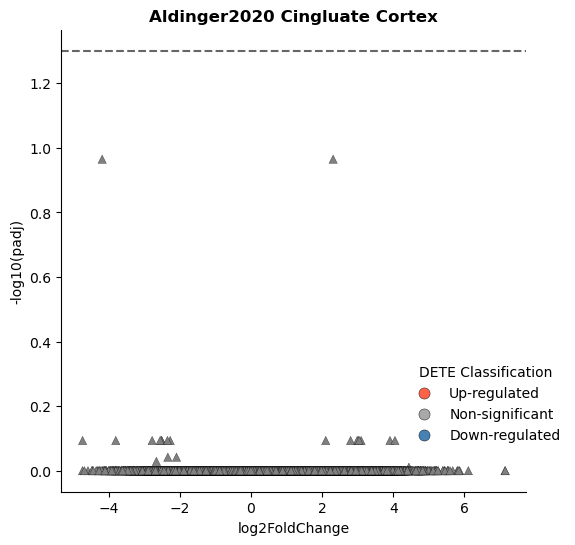

In [5]:

# Organizes the classification, according to the defined values
def organize_classification():
    dea_df['-log10(padj)'] = -np.log10(dea_df['padj'])

    dea_df['Classification'] = dea_df.apply(
        lambda row:
        'Up-regulated' if (row['log2FoldChange'] > 0 and row['padj'] < 0.05)
        else 'Down-regulated' if (row['log2FoldChange'] < 0 and row['padj'] < 0.05)
        else 'Non-significant',
        axis = 1
    )

# Sets the graph's reference lines and labels
def set_lines_and_labels(ax):
    ax.axhline(y = -np.log10(0.05), color = 'black', linestyle = '--', alpha = 0.6)

    ax.set_title('Aldinger2020 Cingluate Cortex', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel('log2FoldChange')
    ax.set_ylabel('-log10(padj)')

# Gets the genes with the biggest change in expression
def get_genes_of_interest():
    significant_df = dea_df[dea_df['Classification'] != 'Non-significant']
    top_up = significant_df.nlargest(5, 'log2FoldChange')['TE'].tolist()
    top_down = significant_df.nsmallest(5, 'log2FoldChange')['TE'].tolist()
    genes_of_interest = top_up + top_down

    dea_df['Classification'] = np.where(dea_df['TE'].isin(genes_of_interest), 
                                        'GOI_' + dea_df['Classification'],
                                        dea_df['Classification'])
    
    return genes_of_interest

# Sets the genes of interest's names on the graph
def set_genes_of_interest_legend(ax):
    global genes_of_interest
    genes_of_interest = get_genes_of_interest()
    texts = []
    for i, row in dea_df.iterrows():
        if row['TE'] in genes_of_interest:
            texts.append(ax.text(row['log2FoldChange'], row['-log10(padj)'], row['TE'],
                         fontsize = 7, color = 'black', fontweight = 'semibold'))
            
    adjust_text(texts, expand_points = (1.5, 1.5), arrowprops = dict(arrowstyle = '-', color = 'black', lw = 0.8), save_steps = False)
    print(texts)

# Sets the main chart legend on the plot
def set_plot_legends(ax):
    #set_genes_of_interest_legend(ax)
    legend_elements = [Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'tomato',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3, 
                            label = 'Up-regulated'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'darkgray',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Non-significant'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'steelblue',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Down-regulated')]
    ax.legend(handles = legend_elements, title = 'DETE Classification', bbox_to_anchor = (1.1, 0.3), frameon = False)

# Main function, gets the volcano plot
def get_volcano_plot():
    organize_classification() # Organiza-se primeiro a tabela com a classificação
    print(dea_df['Classification'].value_counts())
    
    print('Total tes:')
    print(len(expression_df))
    
    intergenic_df = pd.read_csv(INTERGENIC_FILE, sep = '\t', header = None, comment = '#')
    intergenic_df = intergenic_df[intergenic_df.iloc[:, -1] > 4000]
    print(intergenic_df.shape[0])

    intergenic_df = intergenic_df.rename(columns = {intergenic_df.columns[3] : 'TE'})
    intergenic_dete_df = intergenic_df.merge(dea_df, on = 'TE', how = 'inner')
    print(intergenic_dete_df)
    intergenic_dete_df = intergenic_dete_df[intergenic_dete_df['Classification'] != 'Non-significant']
    print('intergenic dete')
    print(intergenic_dete_df.shape[0])

    fig, ax = plt.subplots(figsize = (6, 6)) # Criamos o gráfico
    
    palette_dea = {'GOI_Up-regulated' : 'tomato',
                   'GOI_Down-regulated' : 'steelblue',
                   'Up-regulated' : 'darksalmon',
                   'Down-regulated' : 'lightsteelblue',
                   'Non-significant' : 'gray'}
    
    sns.scatterplot(data = dea_df,  
                    x = 'log2FoldChange', 
                    y = '-log10(padj)',
                    palette = palette_dea, 
                    hue = 'Classification', 
                    edgecolor = 'black',
                    linewidth = 0.2, 
                    legend = False, marker = '^')
    
    set_lines_and_labels(ax) # Colocamos as labels que queremos
    set_plot_legends(ax) # Colocamos as legendas por último
    sns.despine()
    plt.show()
    
get_volcano_plot()



PCA - Data frame

In [6]:
# Variables
TEs = expression_df.iloc[:, 0]
counts = expression_df.iloc[:, 1:]
clinical_data = pd.read_csv(CLINICAL_DATA)

# Process counts
library_size = counts.sum(axis = 0)
cpm_df = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm_df + 1)
print(log2cpm_df.head())

# Process clinical data
clinical_data = clinical_data[['Sample Name', 'Condition', 'Run']]

# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# PCA data frame
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)])
pca_df.reset_index(names = 'Sample Name', inplace = True)
pca_df = pca_df.merge(clinical_data, on = 'Sample Name', how = 'left')

pca_df.head()

   GSM3673208  GSM3673209  GSM3673210  GSM3673211  GSM3673212  GSM3673213  \
0    1.581710    2.494873    1.657458    1.898926    3.180906    2.126197   
1    2.803172    6.187258    6.820680    2.691246    6.832418    3.318327   
2    0.000000    2.494873    2.408495    0.000000    3.852792    0.000000   
3    2.803172    0.000000    0.000000    2.348808    1.883460    0.000000   
4    5.667640    2.991895    3.557411    4.596906    3.555615    4.860322   

   GSM3673214  GSM3673215  
0    1.854819    2.257288  
1    5.283456    3.097920  
2    1.854819    2.594841  
3    0.000000    1.176518  
4    3.344790    3.893689  


,Sample Name,PC1,PC2,Condition,Run
0,GSM3673208,169.482827,-33.818970,Ctrl,SRR8734756
1,GSM3673209,-99.312226,138.867512,Ctrl,SRR8734757
2,GSM3673210,-77.144990,91.712947,Ctrl,SRR8734758
3,GSM3673211,173.460092,-36.255363,Ctrl,SRR8734759
4,GSM3673212,-203.059760,-200.553283,RTT,SRR8734760


PCA - Graph

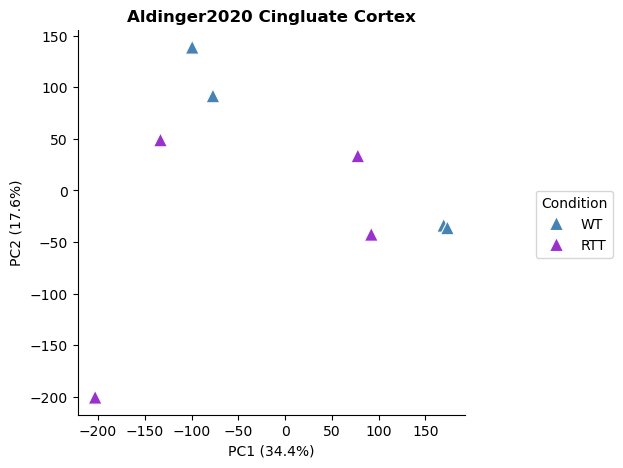

In [7]:
fig, ax = plt.subplots(figsize = (5, 5))
palette_pca = {'WT' : 'steelblue',
               'RTT' : 'darkorchid'}

pca_df['Condition'] = pca_df['Condition'].replace({"Ctrl" : "WT"})
sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', hue = 'Condition', palette = palette_pca, s = 100, marker = '^')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)") # f-string é uma forma moderna de formatar strings em python, valor da variância * 100 para meter em percentagem e dps coloca só com uma casa decimal
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Aldinger2020 Cingluate Cortex", fontweight = 'bold', fontsize = 12)
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))
sns.despine()
plt.show()


Boxplot

In [8]:
# Assemble the new table
log2cpm_df.insert(0, 'TE', TEs)
goi_df = log2cpm_df[log2cpm_df['TE'].isin(genes_of_interest)]

long_df = goi_df.melt(id_vars = 'TE', var_name = 'Sample_Name', value_name = 'log2(CPM)')
long_df = long_df.merge(clinical_data, on = 'Sample_Name', how = 'left')

print(clinical_data.head())

# Assemble the plot

fig, ax = plt.subplots(figsize = (12, 12))

palette_boxplot = {'RTT' : 'tomato',
                   'Ctrl' : 'steelblue'}

sns.boxplot(data = long_df, x = 'TE', y = 'log2(CPM)', hue = 'Condition', palette = palette_boxplot,
                fliersize = 2, linewidth = 2)

ax.set_title('Boxplot - TEs - Cingluate Cortex', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('TEs')
ax.set_ylabel('log2(CPM)')
ax.tick_params(axis = 'x', rotation = 45)



TypeError: only list-like objects are allowed to be passed to isin(), you passed a `NoneType`